In [1]:
import requests
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
from datetime import datetime, timezone
from scipy.interpolate import PchipInterpolator
from scipy.interpolate import LinearNDInterpolator
from scipy.interpolate import RBFInterpolator

# Question: Will BTC hit 100000 by 31DEC26?

target_expiry_str = "25DEC26"
target_expiry = datetime.strptime(target_expiry_str, "%d%b%y").strftime("%Y%m%d")
target_expiry_dt = datetime.strptime(str(target_expiry), "%Y%m%d").replace(tzinfo=timezone.utc)
required_strike = 100000.0

print("target_expiry:", target_expiry)

target_expiry: 20261225


In [53]:
class OptionSurface:

    def initialize(self, currencies, exchanges):
        self.data = {}

        for currency in currencies:
            weighted_spot = self.get_weighted_spot(currency, exchanges)
            curve_df = self.get_curve_df(currency, exchanges)
            surface_df = self.get_surface(currency, exchanges)
            f_variance = self.build_variance_surface(surface_df)

            self.data[currency] = {
                "weighted_spot": weighted_spot,
                "curve_df": curve_df,
                "surface_df": surface_df,
                "f_variance": f_variance
            }

    def get_weighted_spot(self, currency, exchanges):

        spots = [ex.data[currency]["spot"] for ex in exchanges if currency in ex.data]
        weights = [ex.data[currency]["volume"] for ex in exchanges if currency in ex.data]

        weighted_spot = np.average(spots, weights=weights)

        return weighted_spot

    def get_curve_df(self, currency, exchanges):
            
        dfs = [ex.data[currency]["curve_df"] for ex in exchanges if currency in ex.data]

        curve_df = pd.concat(dfs, ignore_index=True)

        curve_df = (curve_df.groupby("strike").apply(
            lambda x: np.average(x.mark_iv, weights=x.open_interest_notional)).reset_index(name="mark_iv")
        )

        return curve_df

    def get_surface(self, currency, exchanges):
    
        dfs = [ex.data[currency]["df"] for ex in exchanges if currency in ex.data]

        surface_df = pd.concat(dfs, ignore_index=True)

        surface_df = surface_df.groupby(["strike", "T"]).apply(
            lambda x: np.average(x.total_variance, weights=x.open_interest_notional)).reset_index(name="total_variance")
        
        return surface_df

    # def build_variance_surface(self, surface_df):
    
    #     points = np.column_stack([surface_df["strike"], surface_df["T"]])
    #     values = surface_df["total_variance"]

    #     f_variance = LinearNDInterpolator(points, values)

    #     return f_variance

    # def build_variance_surface(self, surface_df):
        
    #     points = np.column_stack([surface_df["strike"], surface_df["T"]])
    #     values = surface_df["total_variance"]

    #     f_variance = RBFInterpolator(
    #         points,
    #         values,
    #         kernel="thin_plate_spline"
    #     )

    #     return f_variance

    def build_variance_surface(self, surface_df):
            
        points = np.column_stack([surface_df["strike"], surface_df["T"]])
        values = surface_df["total_variance"]

        f_variance = RBFInterpolator(
            points,
            values,
            kernel="thin_plate_spline",
            smoothing=0.001
        )

        return f_variance

    def get_iv_from_curve(self, exchange, currency, required_strike):

        curve_df = exchange.data[currency]["curve_df"]

        # Question: Will BTC hit 100000 by 31DEC26?

        # It prevents wild overshoots and spurious oscillations found in standard cubic splines, 
        # making it ideal for monotonic data, bounded physical measurements, and financial curves
        f = PchipInterpolator(curve_df.strike, curve_df.mark_iv)

        iv = float(f(required_strike))

        print(f"{currency} {required_strike} strike iv: {iv}")

        return iv

    def get_iv_from_surface(self, exchange, currency, required_strike, T):

        f_variance = exchange.data[currency]["f_variance"]

        print("required_strike:", required_strike, "T:", T)

        # total_variance = f_variance(required_strike, T)

        total_variance = f_variance(np.array([[required_strike, T]]))[0]
        total_variance = np.maximum(total_variance, 0)

        if np.isnan(total_variance):
            return None


        iv = np.sqrt(total_variance / T)

        return float(iv)

    def plot_curve(self, exchange, currency, exchange_name, target_expiry_str):
    
        curve_df = exchange.data[currency]["curve_df"]
    
        plt.plot(curve_df.strike,
                curve_df.mark_iv * 100,   # convert decimal IV to %
                marker="o"
            )
        
        plt.xlabel("Strike")
        plt.ylabel("Implied Volatility (%)")
        plt.title(f"{exchange_name} {currency} {target_expiry_str} IV Smile")
        plt.grid(True)

        plt.show()

    def plot_surface(self, exchange, currency):

        surface_df = exchange.data[currency]["surface_df"]

        fig = plt.figure(figsize=(10, 7))
        
        ax = fig.add_subplot(111, projection="3d")

        # Create grid
        strike_grid = np.linspace(surface_df["strike"].min(), surface_df["strike"].max(), 50)

        T_grid = np.linspace(surface_df["T"].min(), surface_df["T"].max(), 50)

        X, Y = np.meshgrid(strike_grid, T_grid)

        query_points = np.column_stack([
            X.ravel(),
            Y.ravel()
        ])

        # Query interpolator
        f_variance = exchange.data[currency]["f_variance"]
        # variance_grid = f_variance(X, Y)
        variance_grid = f_variance(query_points).reshape(X.shape)
        variance_grid = np.maximum(variance_grid, 0)

        print("variance min:", np.nanmin(variance_grid))
        print("variance max:", np.nanmax(variance_grid))

        print("T min:", np.nanmin(Y))
        print("T max:", np.nanmax(Y))

        print("negative variance count:", np.sum(variance_grid < 0))
        print("zero T count:", np.sum(Y == 0))
        print("nan variance count:", np.sum(np.isnan(variance_grid)))

        # Convert variance back to IV
        IV_grid = np.sqrt(variance_grid / Y)

        # Plot surface
        ax.plot_surface(X, Y, IV_grid, cmap="viridis", alpha=0.8)

        mark_iv = np.sqrt(surface_df["total_variance"] / surface_df["T"])

        # Plot original points
        ax.scatter(
            surface_df["strike"],
            surface_df["T"],
            mark_iv,
            color="red",
            s=20
        )

        ax.set_xlabel("Strike")
        ax.set_ylabel("Time to Expiry (years)")
        ax.set_zlabel("Implied Volatility")

        plt.show()

    def prob_finish(self, spot, required_strike, iv, T, r=0):

        d2 = (np.log(spot / required_strike) + (r - 0.5 * iv ** 2) * T) / (iv * np.sqrt(T))

        p_finish_above = norm.cdf(d2)
        p_finish_below = 1 - p_finish_above

        print("p_finish_above:", p_finish_above, "p_finish_below:", p_finish_below)

        return p_finish_above, p_finish_below

    def prob_touch(self, spot, required_strike, iv, T, r=0, paths=100000, time_steps=365):

        # dS = rSdt + σSdW
        dt = T / time_steps
        Z = np.random.normal(0, 1, size=(paths, time_steps)) # vectorization

        daily_return = ((r - 0.5 * iv ** 2) * dt + iv * np.sqrt(dt) * Z)

        prices = spot * np.exp(np.cumsum(daily_return, axis=1))

        hit_above = prices.max(axis=1) >= required_strike
        hit_below = prices.min(axis=1) <= required_strike

        p_touch_above = hit_above.mean()
        p_touch_below = hit_below.mean()

        print("p_touch_above:", p_touch_above, "p_touch_below:", p_touch_below)

        return p_touch_above, p_touch_below

s = OptionSurface()

In [33]:
class Deribit:
    def __init__(self, currencies, target_expiry):
         self.data = {}

         for currency in currencies:
            spot, volume = self.get_spot(currency)
            df = self.get_df(currency)
            curve_df = self.get_curve_df(df, target_expiry)

            self.data[currency] = {
                "spot": spot,
                "volume": volume,
                "df": df,
                "curve_df": curve_df
            }

    def get_spot(self, currency):
        url = "https://www.deribit.com/api/v2/public/ticker"
        params = {"instrument_name": f"{currency}_USDT"}

        data = requests.get(url, params=params).json()["result"]
        
        spot = float(data["last_price"])
        volume = float(data["stats"]["volume"])

        print("spot:", spot, "volume24h:", volume)

        return spot, volume

    def get_df(self, currency):
        
        url = "https://www.deribit.com/api/v2/public/get_instruments"
        params = {
            "currency": f"{currency}",
            "kind": "option"
        }

        instruments = requests.get(url=url, params=params).json()["result"]
        instruments_df = pd.DataFrame(instruments)

        url = "https://www.deribit.com/api/v2/public/get_book_summary_by_currency"
        params = {
            "currency": f"{currency}",
            "kind": "option"
        }

        quotes = requests.get(url=url, params=params).json()["result"]
        quotes_df = pd.DataFrame(quotes)

        df = instruments_df.merge(quotes_df, on="instrument_name", how="left")
        df["open_interest_notional"] = df["open_interest"] * df["contract_size"]
        df["mark_iv"] = df["mark_iv"].astype(float) / 100

        parts = df["instrument_name"].str.split("-")

        df["expiry"] = pd.to_datetime(parts.str[1], format="%d%b%y").dt.strftime("%Y%m%d")
        df["expiry_dt"] = pd.to_datetime(parts.str[1], format="%d%b%y", utc=True)
        df["T"] = (df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        df["total_variance"] = df["mark_iv"] ** 2 * df["T"]

        df = df[df["T"] > 0] # remove expired options
        df = df[df["open_interest_notional"] >= 10]
        df = df.sort_values(["expiry", "strike"])

        return df

    def get_curve_df(self, df, target_expiry):

        curve_df = df[
            (df["expiry"] == target_expiry) &
            (df["option_type"] == "call")
        ]

        curve_df = curve_df.sort_values("strike")

        return curve_df

deribit = Deribit(currencies=["BTC", "ETH"], target_expiry=target_expiry)

spot: 64304.0 volume24h: 4.4701
spot: 1906.3 volume24h: 11.5086


In [56]:
deribit.data["ETH"]["df"].head()

,state,price_index,kind,instrument_name,instrument_type,maker_commission,taker_commission,underlying_type,instrument_id,expiration_timestamp,...,base_currency_y,quote_currency_y,estimated_delivery_price,volume_usd,mid_price,open_interest_notional,expiry,expiry_dt,T,total_variance
39,open,eth_usd,option,ETH-8AUG26-1600-P,reversed,0.0003,0.0003,crypto,669966,1786176000000,...,ETH,ETH,1902.63,0.19,NaN,567.0,20260808,2026-08-08 00:00:00+00:00,0.001956,0.001268
41,open,eth_usd,option,ETH-8AUG26-1700-P,reversed,0.0003,0.0003,crypto,669968,1786176000000,...,ETH,ETH,1902.63,4.76,NaN,145.0,20260808,2026-08-08 00:00:00+00:00,0.001956,0.001033
43,open,eth_usd,option,ETH-8AUG26-1720-P,reversed,0.0003,0.0003,crypto,669970,1786176000000,...,ETH,ETH,1902.63,7.63,NaN,44.0,20260808,2026-08-08 00:00:00+00:00,0.001956,0.001033
45,open,eth_usd,option,ETH-8AUG26-1740-P,reversed,0.0003,0.0003,crypto,669972,1786176000000,...,ETH,ETH,1902.63,136.74,0.00015,732.0,20260808,2026-08-08 00:00:00+00:00,0.001956,0.001033
47,open,eth_usd,option,ETH-8AUG26-1750-P,reversed,0.0003,0.0003,crypto,670605,1786176000000,...,ETH,ETH,1902.63,0.00,0.00015,20.0,20260808,2026-08-08 00:00:00+00:00,0.001956,0.000929


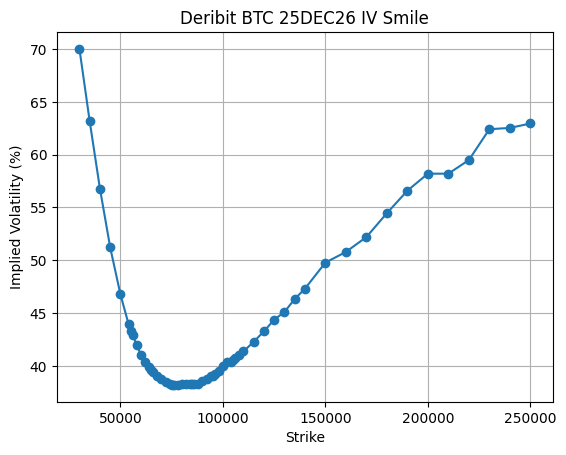

In [34]:
s.plot_curve(exchange=deribit, currency="BTC", exchange_name="Deribit", target_expiry_str=target_expiry_str)

In [34]:
class OKX:
    def __init__(self, currencies, target_expiry):
        self.data = {}
         
        for currency in currencies:
            spot, volume = self.get_spot(currency)
            df = self.get_df(currency)
            curve_df = self.get_curve_df(df, target_expiry)

            self.data[currency] = {
                "spot": spot,
                "volume": volume,
                "df": df,
                "curve_df": curve_df
            }

    def get_spot(self, currency):
        url = "https://www.okx.com/api/v5/market/ticker"
        params = {"instId": f"{currency}-USDT"}

        data = requests.get(url=url, params=params).json()["data"][0]

        spot = float(data["last"])
        volume = float(data["vol24h"])
        print("spot:", spot, "volume24h:", volume)

        return spot, volume

    def get_df(self, currency):

        url = f"https://www.okx.com/api/v5/public/instruments?instType=OPTION&uly={currency}-USD"
        data = requests.get(url).json()
        contract_size = float(data["data"][0]["ctVal"])
        
        url = "https://www.okx.com/api/v5/public/open-interest"
        params = {
            "instType": "OPTION",
            "uly": f"{currency}-USD"
        }

        oi = requests.get(url=url, params=params).json()["data"]
        oi_df = pd.DataFrame(oi)
        oi_df = oi_df.rename(columns={"oi": "open_interest"})
        oi_df["open_interest"] = oi_df["open_interest"].astype(float)
        oi_df["open_interest_notional"] = oi_df["open_interest"] * contract_size

        url = "https://www.okx.com/api/v5/public/opt-summary"
        params = {"uly": f"{currency}-USD"}

        summary = requests.get(url=url, params=params).json()["data"]
        summary_df = pd.DataFrame(summary)
        summary_df = summary_df.rename(columns={"markVol": "mark_iv"})
        summary_df["mark_iv"] = summary_df["mark_iv"].astype(float)

        parts = summary_df["instId"].str.split("-")

        summary_df["ccy"] = parts.str[1]
        summary_df["strike"] = parts.str[3].astype(float)
        summary_df["option_type"] = parts.str[4].map({"C": "call", "P": "put"})
        summary_df["expiry"] = pd.to_datetime(parts.str[2], format="%y%m%d").dt.strftime("%Y%m%d")
        summary_df["expiry_dt"] = pd.to_datetime(parts.str[2], format="%y%m%d", utc=True)
        summary_df["T"] = (summary_df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        summary_df["total_variance"] = summary_df["mark_iv"] ** 2 * summary_df["T"]

        df = summary_df.merge(oi_df, on="instId", how="left")

        df = df[df["T"] > 0] # remove expired options
        df = df[df["ccy"] == "USD"]
        df = df[df["open_interest_notional"] >= 10]
        df = df.sort_values(["expiry", "strike"])

        return df

    def get_curve_df(self, df, target_expiry):

        curve_df = df[
            (df["expiry"] == target_expiry) &
            (df["option_type"] == "call")
        ]

        curve_df = curve_df.sort_values("strike")

        return curve_df

okx = OKX(currencies=["BTC", "ETH"], target_expiry=target_expiry)
okx.data["BTC"]["df"].head()

spot: 64318.0 volume24h: 2949.70135835
spot: 1904.25 volume24h: 49903.60811


,askVol,bidVol,buyApr,delta,deltaBS,distance,fwdPx,gamma,gammaBS,instId,...,expiry,expiry_dt,T,total_variance,instType_y,open_interest,oiCcy,oiUsd,ts_y,open_interest_notional
1027,0.742196015625,0,,-0.000007450164721888623,-0.000007419031794797526,-0.08204364,64273.208019243941655,0.0017167944255262024,0.000000026483224371099774,BTC-USD-260808-59000-P,...,20260808,2026-08-08 00:00:00+00:00,0.001956,0.000267,OPTION,2810.0,28.1,1805793.11,1786085470114,2810.0
1055,0.6054775390625,0,,-0.00023453831472462783,-0.00023337658552780027,-0.06648506,64273.208019243941655,0.04489049018560769,0.0000006912429303310685,BTC-USD-260808-60000-P,...,20260808,2026-08-08 00:00:00+00:00,0.001956,0.000265,OPTION,1522.0,15.22,978093.514,1786085470114,1522.0
1051,0.4882902734375,0.429696640625,0.0349004,-0.0035179454022456584,-0.0034970336877810926,-0.05092648,64273.208019243941655,0.5474514798406034,0.000008409422966463054,BTC-USD-260808-61000-P,...,20260808,2026-08-08 00:00:00+00:00,0.001956,0.000257,OPTION,7084.0,70.84,4552440.508,1786085470114,7084.0
709,0.4101654296875,0.37110300781249994,0.0349004,-0.010533557957348236,-0.010464866451088795,-0.04314719,64273.208019243941655,1.4683234964558314,0.00002252079934738807,BTC-USD-260808-61500-P,...,20260808,2026-08-08 00:00:00+00:00,0.001956,0.000250,OPTION,1518.0,15.18,975522.966,1786085470114,1518.0
1047,0.38086861328125,0.35157179687499995,0.0698008,-0.02705730149873603,-0.026864051476826023,-0.03536789,64273.208019243941655,3.3671369323278815,0.00005155403846578224,BTC-USD-260808-62000-P,...,20260808,2026-08-08 00:00:00+00:00,0.001956,0.000239,OPTION,2634.0,26.34,1692705.858,1786085470114,2634.0


In [17]:
okx.data["BTC"]["curve_df"].head()

,askVol,bidVol,buyApr,delta,deltaBS,distance,fwdPx,gamma,gammaBS,instId,...,expiry,expiry_dt,T,total_variance,instType_y,open_interest,oiCcy,oiUsd,ts_y,open_interest_notional
551,0.7556237231445313,0.6836023828125001,,0.4295799548273609,0.9775038728709303,-0.54481068,65906.6431386007230699,-0.742941728758527,0.00000179303941903803,BTC-USD-261225-30000-C,...,20261225,2026-12-25 00:00:00+00:00,0.385001,0.187006,OPTION,4075.0,40.75,2641500.575,1786007091812,4075.0
544,0.6768885290527344,0.6182948962402344,,0.4901911105432809,0.9644805127588311,-0.46894579,65906.6431386007230699,-0.7862200428680849,0.0000029955763938774185,BTC-USD-261225-35000-C,...,20261225,2026-12-25 00:00:00+00:00,0.385001,0.150225,OPTION,150.0,1.5,97233.15,1786007091812,150.0
528,0.5328458483886718,0.507821484375,,0.5814056195483569,0.9124948983869463,-0.31721602,65906.6431386007230699,-0.6667186173965253,0.000007653825067154225,BTC-USD-261225-45000-C,...,20261225,2026-12-25 00:00:00+00:00,0.385001,0.099661,OPTION,163.0,1.63,105660.023,1786007091812,163.0
525,0.4821867700195312,0.46387625976562497,,0.5986702382590662,0.8625327481180761,-0.24135114,65906.6431386007230699,-0.44547655931433494,0.000011599920347255206,BTC-USD-261225-50000-C,...,20261225,2026-12-25 00:00:00+00:00,0.385001,0.083827,OPTION,510.0,5.1,330592.71,1786007091812,510.0
552,0.4663176611328125,0.45014337707519536,,0.597673705848332,0.836043376499795,-0.21100518,65906.6431386007230699,-0.3222898388497541,0.000013469722474854469,BTC-USD-261225-52000-C,...,20261225,2026-12-25 00:00:00+00:00,0.385001,0.078867,OPTION,50.0,0.5,32411.05,1786007091812,50.0


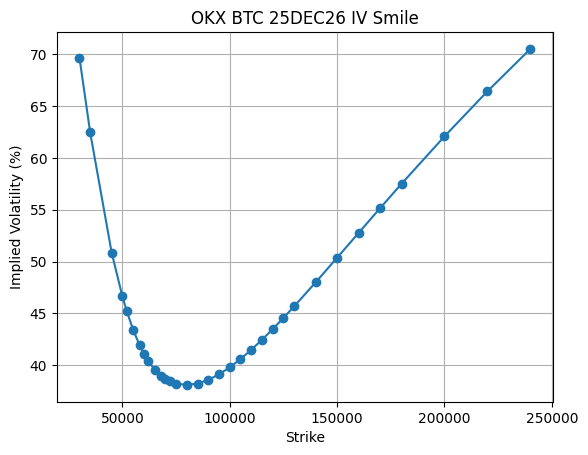

In [20]:
s.plot_curve(curve_df=okx.data["BTC"]["curve_df"], exchange="OKX")

In [35]:
class Bybit:
    def __init__(self, currencies, target_expiry):

        self.data = {}
        
        for currency in currencies:
            spot, volume = self.get_spot(currency)
            df = self.get_df(currency)
            curve_df = self.get_curve_df(df, target_expiry)

            self.data[currency] = {
                "spot": spot,
                "volume": volume,
                "df": df,
                "curve_df": curve_df
            }

    def get_spot(self, currency):
        url = "https://api.bybit.com/v5/market/tickers"
        params = {
            "category": "spot",
            "symbol": f"{currency}USDT"
        }

        data = requests.get(url=url, params=params).json()["result"]["list"][0]
        
        spot = float(data["lastPrice"])
        volume = float(data["volume24h"])
        print("spot:", spot, "volume24h:", volume)

        return spot, volume

    def get_df(self, currency):
        contract_size = 1.0

        url = "https://api.bybit.com/v5/market/tickers"
        params = {
            "baseCoin": f"{currency}",
            "category": "option"
        }

        bybit_data = requests.get(url=url, params=params).json()["result"]["list"]
        df = pd.DataFrame(bybit_data)
        df = df.rename(columns={"markIv": "mark_iv", "openInterest": "open_interest"})

        df["open_interest"] = df["open_interest"].astype(float)
        df["open_interest_notional"] = df["open_interest"] * contract_size
        df["mark_iv"] = df["mark_iv"].astype(float)

        parts = df["symbol"].str.split("-")
        df["strike"] = parts.str[2].astype(float)
        df["option_type"] = parts.str[3].map({"C": "call", "P": "put"})
        df["expiry"] = pd.to_datetime(parts.str[1], format="%d%b%y").dt.strftime("%Y%m%d")
        df["expiry_dt"] = pd.to_datetime(parts.str[1], format="%d%b%y", utc=True)
        df["T"] = (df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        df["total_variance"] = df["mark_iv"] ** 2 * df["T"]

        df = df[df["T"] > 0] # remove expired options
        df = df[df["open_interest_notional"] >= 10]
        df = df.sort_values(["expiry", "strike"])

        return df

    def get_curve_df(self, df, target_expiry):

        curve_df = df[
            (df["expiry"] == target_expiry) &
            (df["option_type"] == "call")
        ]

        curve_df = curve_df.sort_values("strike")

        return curve_df

bybit = Bybit(currencies=["BTC", "ETH"], target_expiry=target_expiry)
bybit.data["BTC"]["df"].head()

spot: 64314.1 volume24h: 6047.510122
spot: 1904.11 volume24h: 44938.53502


,symbol,bid1Price,bid1Size,bid1Iv,ask1Price,ask1Size,ask1Iv,lastPrice,highPrice24h,lowPrice24h,...,theta,predictedDeliveryPrice,change24h,open_interest_notional,strike,option_type,expiry,expiry_dt,T,total_variance
311,BTC-8AUG26-60000-P-USDT,0,0,0,5,39.59,0.5396,5,10,5,...,-3.84641844,0,-0.5,17.18,60000.0,put,20260808,2026-08-08 00:00:00+00:00,0.001956,0.000380
313,BTC-8AUG26-61000-P-USDT,0,0,0,5,35,0.4244,5,15,5,...,-11.079297,0,-0.66666667,33.64,61000.0,put,20260808,2026-08-08 00:00:00+00:00,0.001956,0.000302
323,BTC-8AUG26-62000-P-USDT,10,59.11,0.3407,15,51.24,0.3644,10,45,10,...,-33.24277928,0,-0.71428572,39.59,62000.0,put,20260808,2026-08-08 00:00:00+00:00,0.001956,0.000236
320,BTC-8AUG26-63000-P-USDT,55,61.61,0.3081,60,62.82,0.3159,50,140,45,...,-93.6511219,0,-0.41176471,31.07,63000.0,put,20260808,2026-08-08 00:00:00+00:00,0.001956,0.000186
342,BTC-8AUG26-63500-P-USDT,120,79.87,0.2911,125,39.51,0.2961,115,245,95,...,-140.3947698,0,-0.23333334,21.88,63500.0,put,20260808,2026-08-08 00:00:00+00:00,0.001956,0.000170


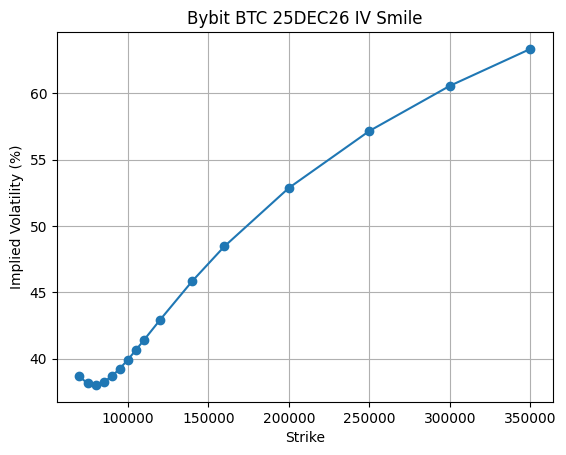

In [39]:
s.plot_curve(exchange=bybit, currency="BTC", exchange_name="Bybit", target_expiry_str=target_expiry_str)

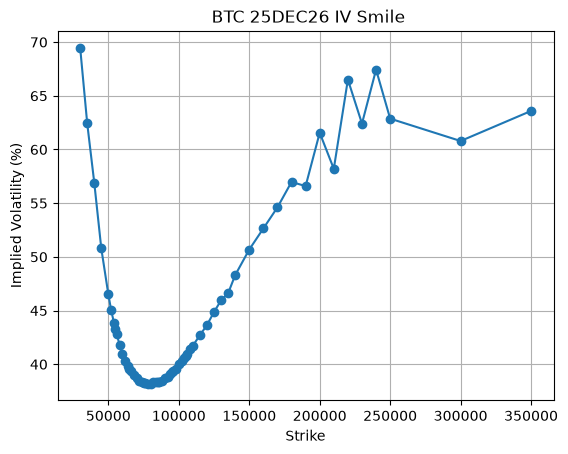

In [54]:
s.initialize(currencies=["BTC", "ETH"], exchanges=[deribit, okx, bybit])
s.plot_curve(exchange=s, currency="BTC", exchange_name="", target_expiry_str=target_expiry_str)

In [49]:
T = (target_expiry_dt - datetime.now(timezone.utc)).total_seconds() / (365 * 24 * 60 * 60)

iv = s.get_iv_from_curve(exchange=s, currency="BTC", required_strike=required_strike)

s.prob_touch(spot=s.data["BTC"]["weighted_spot"], 
                    required_strike=required_strike,
                    iv=iv,
                    T=T,
                    r=0)

s.prob_finish(spot=s.data["BTC"]["weighted_spot"], 
                    required_strike=required_strike, 
                    iv=iv,
                    T=T,
                    r=0)

BTC 100000.0 strike iv: 0.4001278733766081
p_touch_above: 0.0551 p_touch_below: 1.0
p_finish_above: 0.028279166891797023 p_finish_below: 0.971720833108203


(np.float64(0.028279166891797023), np.float64(0.971720833108203))

In [50]:
T = (target_expiry_dt - datetime.now(timezone.utc)).total_seconds() / (365 * 24 * 60 * 60)

iv = s.get_iv_from_surface(exchange=s, currency="BTC", required_strike=required_strike, T=T)
print(iv)

s.prob_touch(spot=s.data["BTC"]["weighted_spot"],
                    required_strike=70000,
                    iv=iv,
                    T=T,
                    r=0)

s.prob_finish(spot=s.data["BTC"]["weighted_spot"], 
                    required_strike=70000, 
                    iv=iv,
                    T=T,
                    r=0)

required_strike: 100000.0 T: 0.38277306455552385
0.3944974992961571
p_touch_above: 0.67383 p_touch_below: 1.0
p_finish_above: 0.31951615982063675 p_finish_below: 0.6804838401793633


(np.float64(0.31951615982063675), np.float64(0.6804838401793633))

variance min: 0.0
variance max: 2.2421875
T min: 0.001955862368557812
T max: 0.8808063473068294
negative variance count: 0
zero T count: 0
nan variance count: 0


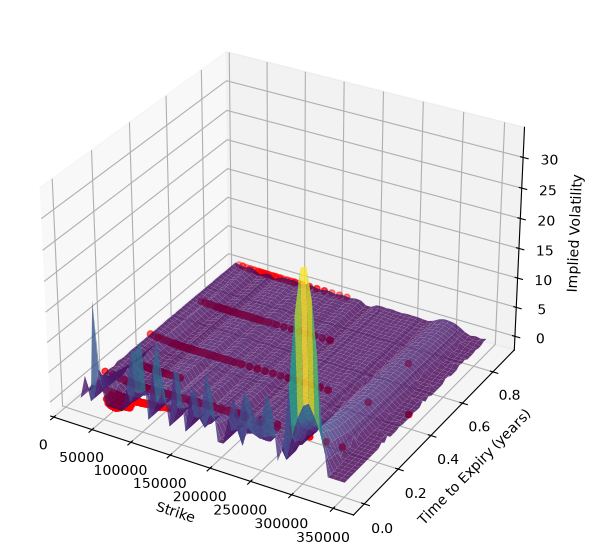

In [55]:
s.plot_surface(exchange=s, currency="BTC")

In [ ]:
# Keep trading journal

# Your thesis.
# Why you think the market is mispriced.
# Position size.
# Exit criteria.
# What actually happened.